# Drift Detection — 03: Gaussian Process Regression

Models each dimension's alignment trajectory as a **Gaussian Process** — a distribution over
smooth functions. Drift = observation falling outside the GP's predictive interval.

The signal taxonomy is **not an input**. Anomalies are detected purely by deviation from the
learned trajectory, without naming the pattern (crash, fade, etc.).

**Doc reference:** `docs/evolution/drift_detection.md § 3.3`

### Key properties

- **Uncertainty-aware natively:** The predictive interval widens during gaps and narrows where data is dense.
- **Handles irregular spacing:** GPs work with arbitrary input spacing — sporadic journaling doesn't break the model.
- **Con:** With ~10-15 data points per dimension, the posterior may be wide (uncertainty bands too generous).
- **Con:** Requires choosing a kernel. Matérn-3/2 is used here (allows non-smooth functions).


In [8]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.9)

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel

# --- Load judge labels (204 personas, 1651 entries, integer {-1, 0, 1} scores) ---
# Using judge labels rather than human annotations: more data (all 204 personas vs 24),
# and clean integer scores (no averaging artefacts).

VALUE_COLS = [
    "alignment_self_direction", "alignment_stimulation", "alignment_hedonism",
    "alignment_achievement", "alignment_power", "alignment_security",
    "alignment_conformity", "alignment_tradition", "alignment_benevolence",
    "alignment_universalism",
]
SHORT_NAMES = [c.replace("alignment_", "") for c in VALUE_COLS]
DIM_LABELS  = ["SD", "ST", "HE", "AC", "PO", "SE", "CO", "TR", "BE", "UN"]

judge_df = pl.read_parquet("../../logs/judge_labels/judge_labels.parquet")
mean_df  = (
    judge_df
    .select(["persona_id", "t_index"] + VALUE_COLS)
    .with_columns([pl.col(c).cast(pl.Float64) for c in VALUE_COLS])
    .sort(["persona_id", "t_index"])
)

registry   = pl.read_parquet("../../logs/registry/personas.parquet").select(
                ["persona_id", "name", "core_values"])
id_to_name = dict(zip(registry["persona_id"].to_list(), registry["name"].to_list()))
id_to_core = dict(zip(registry["persona_id"].to_list(), registry["core_values"].to_list()))

persona_ids = sorted(mean_df["persona_id"].unique().to_list())
print(f"Loaded {len(judge_df)} judge-labelled entries across {len(persona_ids)} personas")

# --- Sample: verify input scores look correct ---
# Pick first persona with ≥5 entries so the sample is representative
sample_pid = next(
    pid for pid in persona_ids
    if mean_df.filter(pl.col("persona_id") == pid).height >= 5
)
sample_data = mean_df.filter(pl.col("persona_id") == sample_pid).head(5)
print(f"\nSample scores (first 5 entries) for '{id_to_name.get(sample_pid, sample_pid)}':")
print(f"  Core values: {id_to_core.get(sample_pid, [])}")
print(sample_data.select(["t_index"] + VALUE_COLS))
print("  Scores are integers in {{-1, 0, +1}} across all 10 Schwartz dimensions")


def get_persona_matrix(pid: str) -> tuple[list[int], np.ndarray]:
    pdata = mean_df.filter(pl.col("persona_id") == pid).sort("t_index")
    return pdata["t_index"].to_list(), np.array([pdata[c].to_list() for c in VALUE_COLS]).T


def get_profile_weights(pid: str) -> np.ndarray:
    core = id_to_core.get(pid, [])
    name_to_idx = {s.lower().replace("-", "_"): i for i, s in enumerate(SHORT_NAMES)}
    w = np.zeros(10)
    for v in core:
        key = v.lower().replace("-", "_").replace(" ", "_")
        if key in name_to_idx:
            w[name_to_idx[key]] = 1.0
    if w.sum() > 0:
        w /= w.sum()
    return w


def core_dim_indices(weights: np.ndarray, w_min: float = 0.15) -> list[int]:
    return [j for j, wj in enumerate(weights) if wj >= w_min]


Loaded 1651 judge-labelled entries across 204 personas

Sample scores (first 5 entries) for 'Megan Torres':
  Core values: ['Achievement', 'Benevolence']
shape: (5, 11)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ t_index ┆ alignment_ ┆ alignment ┆ alignment ┆ … ┆ alignment ┆ alignment ┆ alignment ┆ alignment │
│ ---     ┆ self_direc ┆ _stimulat ┆ _hedonism ┆   ┆ _conformi ┆ _traditio ┆ _benevole ┆ _universa │
│ i64     ┆ tion       ┆ ion       ┆ ---       ┆   ┆ ty        ┆ n         ┆ nce       ┆ lism      │
│         ┆ ---        ┆ ---       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ f64        ┆ f64       ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0       ┆ 0.0        ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ 1       ┆ 0.0        

## GP Implementation

For each persona × core dimension:
1. Fit a GP to (t_index, score) pairs.
2. Predict mean and std at each observed step.
3. Flag steps where the observed score falls below `predicted_mean - n_sigma * std`.

In [9]:
def gp_dimension(
    t_indices: list[int],
    scores_1d: np.ndarray,
    n_sigma: float = 1.5,
    min_train: int = 3,
) -> dict:
    """
    Fit a GP to alignment scores and flag anomalies.

    Parameters
    ----------
    t_indices  : step indices (used as X)
    scores_1d  : (T,) alignment scores
    n_sigma    : alert when score < mean - n_sigma * std
    min_train  : minimum points before making predictions

    Returns
    -------
    dict with keys:
        mean      : (T,) predicted mean
        std       : (T,) predicted std
        lower     : (T,) lower confidence bound (mean - n_sigma * std)
        alerts    : list of t-indices where score < lower bound
    """
    T = len(scores_1d)
    X = np.array(t_indices).reshape(-1, 1).astype(float)
    y = scores_1d.astype(float)

    kernel = ConstantKernel(1.0) * Matern(length_scale=2.0, nu=1.5) + WhiteKernel(noise_level=0.1)
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                   normalize_y=True, random_state=42)

    mean   = np.full(T, np.nan)
    std    = np.full(T, np.nan)
    lower  = np.full(T, np.nan)
    alerts = []

    for t in range(min_train, T):
        # Train on all points up to (but not including) t, then predict at t
        X_train, y_train = X[:t], y[:t]
        X_pred  = X[t:t+1]

        try:
            gpr.fit(X_train, y_train)
            mu, sigma = gpr.predict(X_pred, return_std=True)
            mean[t]  = mu[0]
            std[t]   = sigma[0]
            lower[t] = mu[0] - n_sigma * sigma[0]
            if y[t] < lower[t]:
                alerts.append(t)
        except Exception:
            pass

    return {"mean": mean, "std": std, "lower": lower, "alerts": alerts}


## Run GP on All Personas

In [10]:
N_SIGMA = 1.5
W_MIN   = 0.15

gp_results = {}

for pid in persona_ids:
    t_idx, matrix = get_persona_matrix(pid)
    T = len(t_idx)
    if T < 5:
        continue

    w = get_profile_weights(pid)
    core_j = core_dim_indices(w, W_MIN)

    dim_results = {}
    alerts = []

    for j in core_j:
        out = gp_dimension(t_idx, matrix[:, j], n_sigma=N_SIGMA)
        dim_results[j] = out
        for t in out["alerts"]:
            alerts.append((t, j))

    gp_results[pid] = {
        "name":        id_to_name.get(pid, pid[:8]),
        "core":        id_to_core.get(pid, []),
        "T":           T,
        "t_idx":       t_idx,
        "matrix":      matrix,
        "weights":     w,
        "dim_results": dim_results,
        "alerts":      alerts,
    }

print(f"GP ran on {len(gp_results)} personas\n")
print(f"{'Persona':<25s}  {'Core':<28s}  T  Alerts")
print("-" * 70)
for pid, r in gp_results.items():
    print(f"{r['name']:<25s}  {', '.join(r['core']):<28s}  {r['T']:2d}  {len(r['alerts'])}")


/Users/yuen@backbase.com/Documents/School/twinkl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yuen@backbase.com/Documents/School/twinkl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yuen@backbase.com/Documents/School/twinkl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit a

GP ran on 180 personas

Persona                    Core                          T  Alerts
----------------------------------------------------------------------
Megan Torres               Achievement, Benevolence      10  3
Tariq Mansour              Power, Benevolence             9  0
Noor Haddad                Self-Direction, Tradition     12  1
Lukas Vermeer              Tradition                     12  0
Patricia Moreno            Universalism                   6  0
Roberto Espinoza           Security                       6  0
Chen Wei-Lin               Stimulation                    8  0
Mathilde Delvaux           Tradition                      9  0
Chen Meiling               Benevolence                   11  0
Marcus Chen                Self-Direction                 8  0
Tariq Haddad               Benevolence, Achievement       9  2
Karim Nazari               Hedonism, Self-Direction       9  4
Valentina Reyes            Self-Direction, Benevolence    8  1
Lukas Vermeer      

/Users/yuen@backbase.com/Documents/School/twinkl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yuen@backbase.com/Documents/School/twinkl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yuen@backbase.com/Documents/School/twinkl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit a

## Metrics: Score GP Against Consensus

Evaluate GP against the same consensus labels used in notebooks 01 and 02.
Consensus = ≥4 of 6 rule-based sub-approaches independently flag the same `(persona, t_index)`.

**n_sigma sensitivity sweep:** Rather than re-fitting the GP, stored `mean[t]` and `std[t]`
from `gp_results` are re-used. Alerts are recomputed as `score[t] < mean[t] - n_sigma × std[t]`.

**Caveat:** Consensus labels are derived from rule-based approaches — by construction
rule-based methods score well against their own consensus. GP disagreement is informative.

| Metric | Target |
|---|---|
| Hit Rate | ≥ 80% |
| Precision | > 60% |
| F1 | > 0.5 |
| FPR | < 20% |
| First-alert latency | ≤ 2 steps |

In [11]:
from dataclasses import dataclass
from scipy.special import rel_entr

# --- Inline consensus (identical to notebooks 01 and 02) ---
def _baseline_alerts(matrix, w, delta=0.5, tau=-0.4, c_min=3, w_min=0.15):
    T, K = matrix.shape
    scalar = matrix @ w; state = np.zeros(K); alerts = set()
    for t in range(1, T):
        if scalar[t-1] - scalar[t] > delta: alerts.add(t)
        for j in range(K):
            if w[j] < w_min: state[j] = 0; continue
            if matrix[t, j] < tau: state[j] += 1
            else: state[j] = 0
            if state[j] >= c_min: alerts.add(t)
    return alerts

def _ema_alerts(matrix, w, alpha=0.3, threshold=0.10, w_min=0.15):
    T, K = matrix.shape; ema = np.zeros(K); alerts = set()
    for t in range(T):
        for j in range(K):
            if w[j] < w_min: continue
            ema[j] = alpha * w[j] * max(0., -matrix[t, j]) + (1 - alpha) * ema[j]
            if ema[j] > threshold: alerts.add(t)
    return alerts

def _cusum_alerts(matrix, w, k=0.3, h=1.5, w_min=0.15):
    T, K = matrix.shape; jar = np.zeros(K); alerts = set()
    for t in range(T):
        for j in range(K):
            if w[j] < w_min: continue
            jar[j] = max(0., jar[j] + w[j] * max(0., -matrix[t, j]) - k)
            if jar[j] > h: alerts.add(t)
    return alerts

def _cosine_alerts(matrix, w, threshold=0.0):
    alerts = set()
    for t in range(len(matrix)):
        a = matrix[t]; norm = np.linalg.norm(w) * np.linalg.norm(a)
        if norm > 1e-8 and np.dot(w, a) / norm < threshold: alerts.add(t)
    return alerts

def _cc_alerts(matrix, w, baseline_end=3, n_sigma=2.0, w_min=0.15):
    T, K = matrix.shape
    if baseline_end >= T: return set()
    mu = matrix[:baseline_end].mean(0); sig = matrix[:baseline_end].std(0)
    alerts = set()
    for t in range(baseline_end, T):
        for j in range(K):
            if w[j] >= w_min and matrix[t, j] < mu[j] - n_sigma * sig[j]: alerts.add(t)
    return alerts

def _kl_alerts(matrix, w, baseline_end=3, window=3, kl_thresh=0.15, w_min=0.15):
    T, K = matrix.shape; bins = [-1.5, -0.5, 0.5, 1.5]
    def dist(vals):
        c, _ = np.histogram(vals, bins=bins); d = c.astype(float) + 0.05; return d / d.sum()
    alerts = set()
    for j in range(K):
        if w[j] < w_min: continue
        bd = dist(matrix[:baseline_end, j])
        for t in range(baseline_end + window, T + 1):
            if np.sum(rel_entr(dist(matrix[t-window:t, j]), bd)) > kl_thresh: alerts.add(t - 1)
    return alerts

def compute_consensus(pid):
    t_idx, matrix = get_persona_matrix(pid)
    T = len(t_idx)
    if T < 5: return {}
    w = get_profile_weights(pid)
    be = max(2, min(4, T // 3))
    votes = {t: 0 for t in range(T)}
    for fn, kw in [
        (_baseline_alerts, {}), (_ema_alerts, {}), (_cusum_alerts, {}),
        (_cosine_alerts, {}), (_cc_alerts, {"baseline_end": be}), (_kl_alerts, {"baseline_end": be}),
    ]:
        for t in fn(matrix, w, **kw):
            if t in votes: votes[t] += 1
    return votes


@dataclass
class Metrics:
    hit_rate: float
    precision: float
    f1: float
    fpr: float
    latency: float


def score_gp_nsigma(ns: float, threshold: int = 4) -> Metrics:
    """Score GP using stored mean/std from gp_results — no re-fitting needed."""
    tp = fp = fn = tn = 0
    latencies = []
    for pid, r in gp_results.items():
        sv = compute_consensus(pid)
        crisis     = {t for t, s in sv.items() if s >= threshold}
        non_crisis = {t for t, s in sv.items() if s <  threshold}
        matrix = r["matrix"]
        alerted = set()
        for j, out in r["dim_results"].items():
            y = matrix[:, j]
            for t in range(len(y)):
                if not np.isnan(out["mean"][t]) and y[t] < out["mean"][t] - ns * out["std"][t]:
                    alerted.add(t)
        tp += len(alerted & crisis)
        fp += len(alerted & non_crisis)
        fn += len(crisis - alerted)
        tn += len(non_crisis - alerted)
        if crisis and alerted:
            fc = min(crisis)
            fa = min((t for t in alerted if t >= fc), default=None)
            if fa is not None:
                latencies.append(fa - fc)
    hit  = tp / max(tp + fn, 1)
    prec = tp / max(tp + fp, 1)
    f1   = 2 * hit * prec / max(hit + prec, 1e-9)
    fpr  = fp / max(fp + tn, 1)
    lat  = float(np.mean(latencies)) if latencies else float("nan")
    return Metrics(hit, prec, f1, fpr, lat)


print("GP: n_sigma sensitivity vs consensus labels\n")
print(f"{'n_sigma':>7s}  {'Hit%':>6s}  {'Prec%':>6s}  {'F1':>6s}  {'FPR%':>6s}  {'Lat':>5s}")
print("-" * 55)
gp_sweep = {}
for ns in [1.0, 1.5, 2.0, 2.5]:
    m = score_gp_nsigma(ns)
    gp_sweep[ns] = m
    marker = " ←" if ns == N_SIGMA else ""
    print(f"{ns:>7.1f}  {m.hit_rate*100:>5.1f}{'✓' if m.hit_rate >= 0.80 else ' '}  "
          f"{m.precision*100:>5.1f}{'✓' if m.precision >= 0.60 else ' '}  "
          f"{m.f1:>6.3f}  "
          f"{m.fpr*100:>5.1f}{'✓' if m.fpr <= 0.20 else ' '}  "
          f"{m.latency:>5.1f}{marker}")

best_ns = max(gp_sweep, key=lambda ns: gp_sweep[ns].f1)
m_best  = gp_sweep[best_ns]
print(f"\nBest n_sigma={best_ns}:  Hit={m_best.hit_rate*100:.1f}%  "
      f"Prec={m_best.precision*100:.1f}%  F1={m_best.f1:.3f}  "
      f"FPR={m_best.fpr*100:.1f}%  Lat={m_best.latency:.1f}")
print("Note: GP alerts only start at t≥min_train (default 3). Steps 0–2 are never flagged.")

GP: n_sigma sensitivity vs consensus labels

n_sigma    Hit%   Prec%      F1    FPR%    Lat
-------------------------------------------------------
    1.0   57.9    24.7    0.347   14.6✓    0.6
    1.5   43.0    29.7    0.351    8.5✓    0.2 ←
    2.0   37.2    35.7    0.364    5.6✓    0.0
    2.5   32.2    42.9    0.368    3.6✓    0.0

Best n_sigma=2.5:  Hit=32.2%  Prec=42.9%  F1=0.368  FPR=3.6%  Lat=0.0
Note: GP alerts only start at t≥min_train (default 3). Steps 0–2 are never flagged.


## Visualise GP Fit

For each persona: alignment scores with GP predictive mean, confidence band, and flagged anomalies.

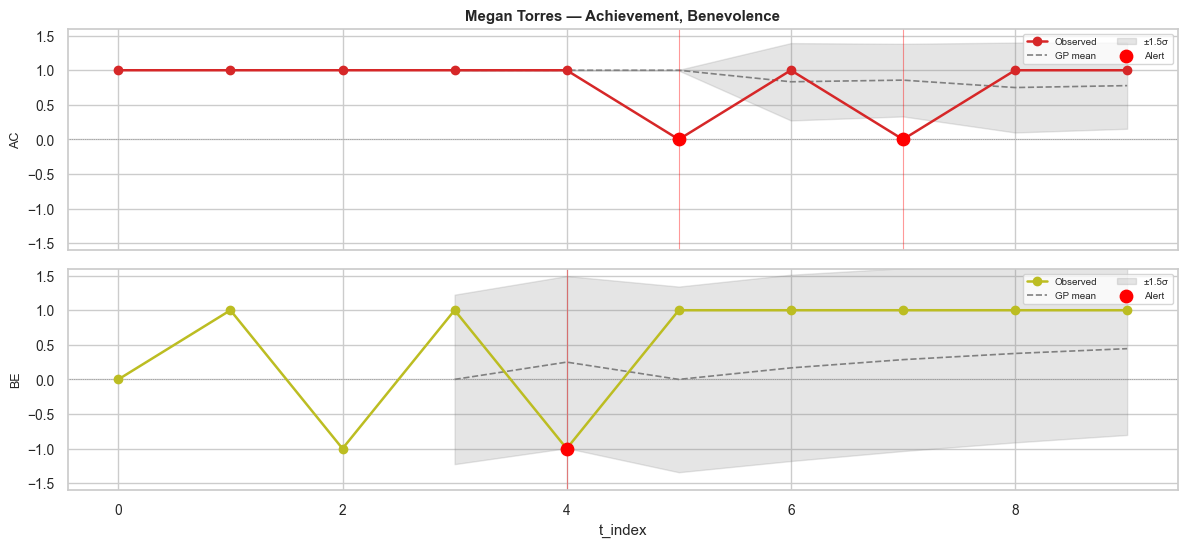

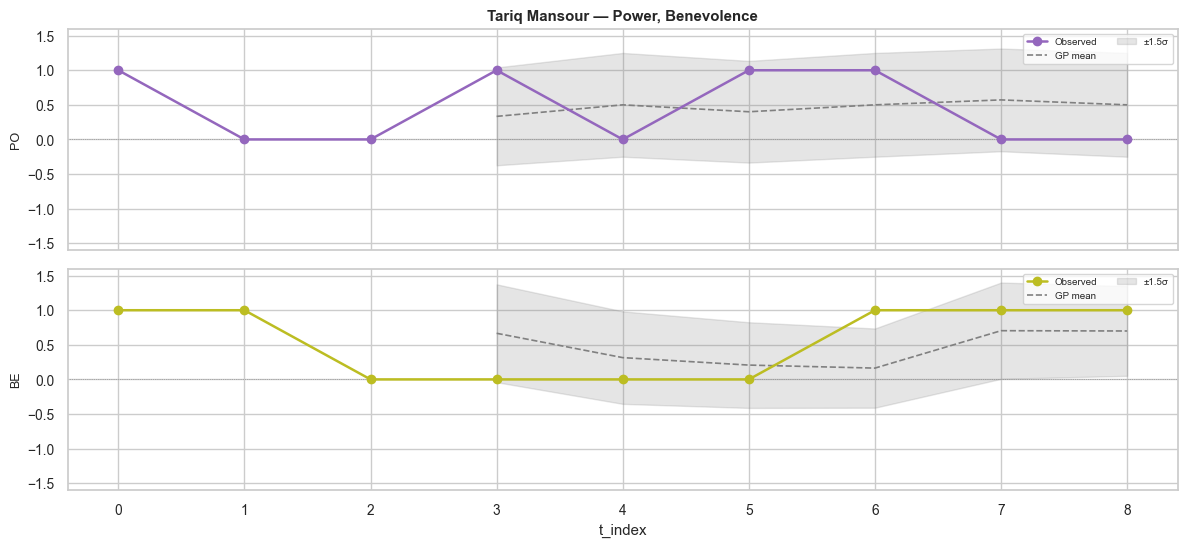

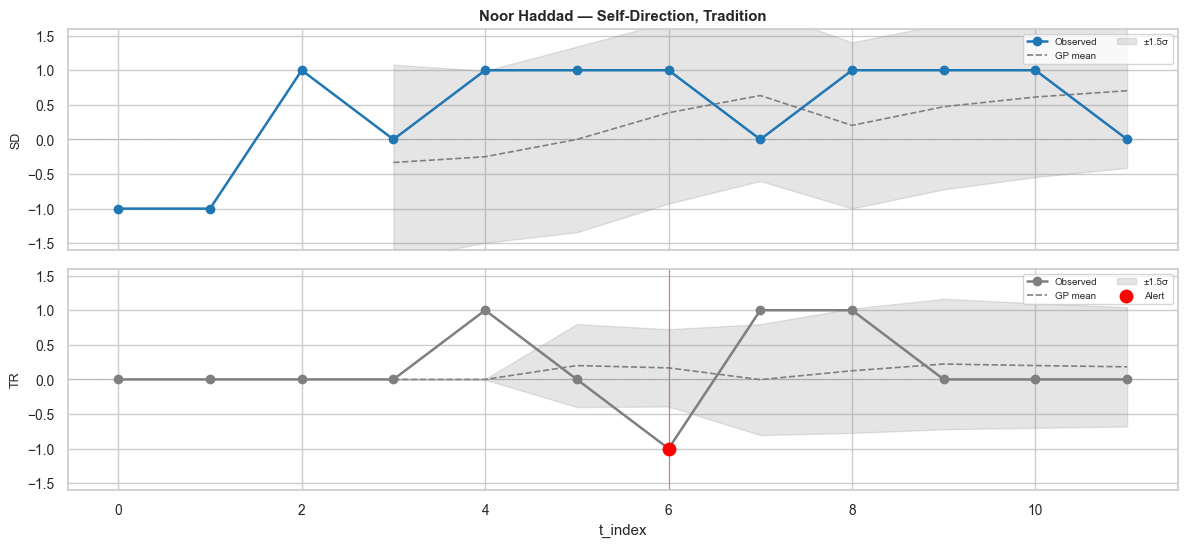

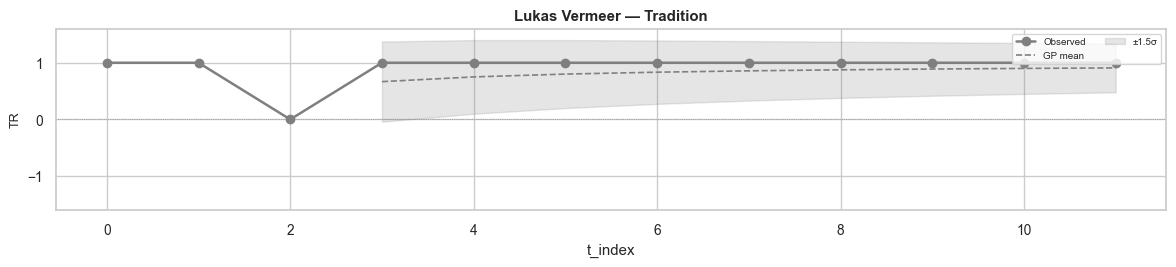

In [12]:
palette = sns.color_palette("tab10", n_colors=10)


def plot_gp_persona(pid: str):
    r = gp_results[pid]
    matrix = r["matrix"]
    T = r["T"]
    core_j = list(r["dim_results"].keys())
    if not core_j:
        return

    fig, axes = plt.subplots(len(core_j), 1, figsize=(12, 2.8 * len(core_j)), sharex=True)
    if len(core_j) == 1:
        axes = [axes]

    xs = list(range(T))

    for ax, j in zip(axes, core_j):
        out = r["dim_results"][j]
        scores = matrix[:, j]
        color = palette[j]

        ax.plot(xs, scores, "o-", color=color, lw=1.8, zorder=4, label="Observed")

        valid = ~np.isnan(out["mean"])
        if valid.any():
            ax.plot(np.where(valid)[0], out["mean"][valid], "--", color="grey",
                    lw=1.2, label="GP mean")
            ax.fill_between(np.where(valid)[0],
                            out["lower"][valid],
                            out["mean"][valid] + (out["mean"][valid] - out["lower"][valid]),
                            color="grey", alpha=0.2, label=f"±{N_SIGMA}σ")

        for t in out["alerts"]:
            ax.scatter([t], [scores[t]], color="red", s=80, zorder=5, label="Alert" if t == out["alerts"][0] else "")
            ax.axvline(t, color="red", lw=0.8, alpha=0.4)

        ax.axhline(0, color="grey", lw=0.5, ls=":")
        ax.set_ylim(-1.6, 1.6)
        ax.set_ylabel(DIM_LABELS[j], fontsize=9)
        ax.legend(fontsize=7, loc="upper right", ncol=2)

    axes[0].set_title(f"{r['name']} — {', '.join(r['core'])}", fontweight="bold")
    axes[-1].set_xlabel("t_index")
    plt.tight_layout()
    plt.show()


for pid in list(gp_results.keys())[:4]:
    plot_gp_persona(pid)


## Kernel Sensitivity

Compare Matérn-1/2, Matérn-3/2, and RBF kernels on an example persona.

/Users/yuen@backbase.com/Documents/School/twinkl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yuen@backbase.com/Documents/School/twinkl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yuen@backbase.com/Documents/School/twinkl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit a

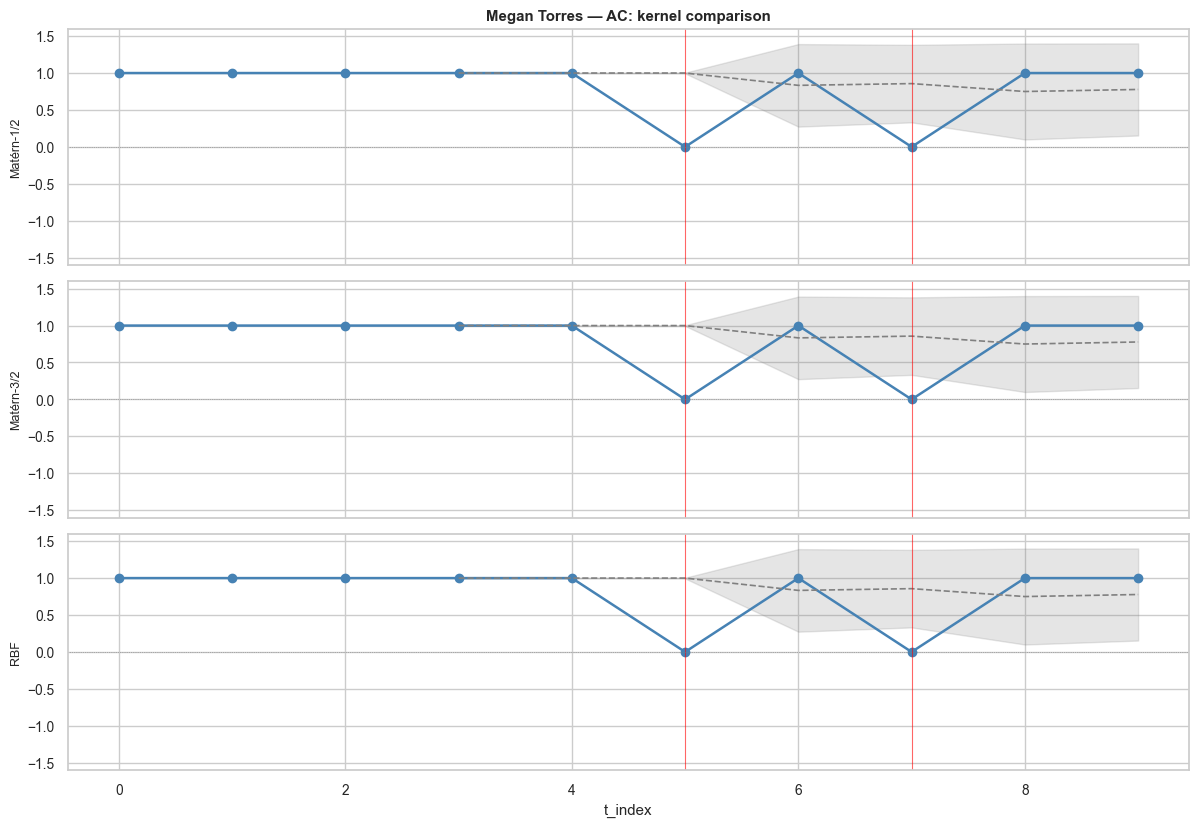

In [13]:
from sklearn.gaussian_process.kernels import RBF

example_pid = next(pid for pid, r in gp_results.items() if r["T"] >= 6 and r["dim_results"])
example_r   = gp_results[example_pid]
example_j   = list(example_r["dim_results"].keys())[0]
t_idx_ex    = example_r["t_idx"]
scores_ex   = example_r["matrix"][:, example_j]

kernels = {
    "Matérn-1/2": ConstantKernel(1.0) * Matern(length_scale=2.0, nu=0.5) + WhiteKernel(0.1),
    "Matérn-3/2": ConstantKernel(1.0) * Matern(length_scale=2.0, nu=1.5) + WhiteKernel(0.1),
    "RBF":        ConstantKernel(1.0) * RBF(length_scale=2.0)             + WhiteKernel(0.1),
}

fig, axes = plt.subplots(len(kernels), 1, figsize=(12, 2.8 * len(kernels)), sharex=True)

for ax, (kname, kern) in zip(axes, kernels.items()):
    out = gp_dimension(t_idx_ex, scores_ex, n_sigma=N_SIGMA)
    T = len(scores_ex)
    xs = list(range(T))
    valid = ~np.isnan(out["mean"])

    ax.plot(xs, scores_ex, "o-", color="steelblue", lw=1.8)
    if valid.any():
        ax.plot(np.where(valid)[0], out["mean"][valid], "--", color="grey", lw=1.2)
        ax.fill_between(np.where(valid)[0],
                        out["lower"][valid],
                        out["mean"][valid] + (out["mean"][valid] - out["lower"][valid]),
                        color="grey", alpha=0.2)
    for t in out["alerts"]:
        ax.axvline(t, color="red", lw=0.8, alpha=0.6)
    ax.axhline(0, color="grey", lw=0.5, ls=":")
    ax.set_ylim(-1.6, 1.6)
    ax.set_ylabel(kname, fontsize=9)

axes[0].set_title(f"{example_r['name']} — {DIM_LABELS[example_j]}: kernel comparison",
                  fontweight="bold")
axes[-1].set_xlabel("t_index")
plt.tight_layout()
plt.show()


## Limitations

- **Wide posteriors:** With ≤15 data points per dimension, confidence bands are often too generous — few anomalies detected.
- **Kernel choice matters:** Matérn-3/2 is a reasonable default for non-smooth value trajectories, but the optimal kernel is not obvious.
- **Discrete score space:** GP assumes continuous observations. {-1, 0, +1} scores violate this assumption; results are approximate.
- **No profile weights `w_u` natively:** GP operates per-dimension. Must suppress alerts on low-weight dimensions externally.

GP regression is a lateral upgrade — most valuable if irregular journaling (skipped weeks, burst entries) proves problematic for weekly aggregation. See `docs/evolution/drift_detection.md § 3.3`.